In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_samples



In [9]:
df = pd.DataFrame(load_iris().data)

In [3]:
df.head(6)

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4


In [6]:
df.columns = load_iris().feature_names
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [13]:
scaler = StandardScaler()

x = scaler.fit_transform(df)

In [14]:
ks = [2, 3, 4, 5,6,7,8,9,10]

inertias = []
silhouette_scores = []


for k in ks:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(X)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(x, labels)
    )
    
for k, inertia, score in zip(
    ks,
    inertias,
    silhouette_scores
):

    print(
        f"k = {k} | "
        f"Inertia = {inertia:.2f} | "
        f"Silhouette = {score:.2f}"
    )

k = 2 | Inertia = 222.36 | Silhouette = 0.58
k = 3 | Inertia = 191.02 | Silhouette = 0.48
k = 4 | Inertia = 114.35 | Silhouette = 0.39
k = 5 | Inertia = 91.05 | Silhouette = 0.35
k = 6 | Inertia = 81.55 | Silhouette = 0.33
k = 7 | Inertia = 80.78 | Silhouette = 0.27
k = 8 | Inertia = 64.43 | Silhouette = 0.34
k = 9 | Inertia = 55.71 | Silhouette = 0.32
k = 10 | Inertia = 51.12 | Silhouette = 0.34


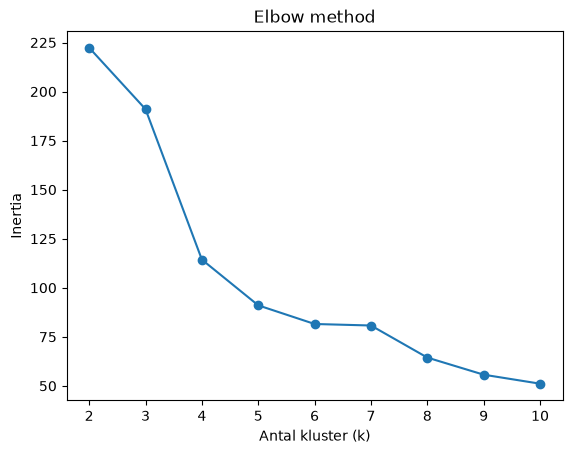

In [16]:
# Inertia

plt.plot(
    ks,
    inertias,
    marker="o"
)

plt.xlabel("Antal kluster (k)")
plt.ylabel("Inertia")
plt.title("Elbow method")

plt.show()

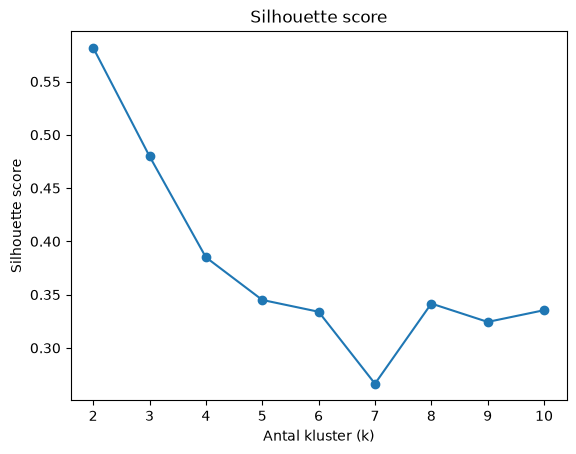

In [17]:
# Silhouette score

plt.plot(
    ks,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Antal kluster (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score")

plt.show()

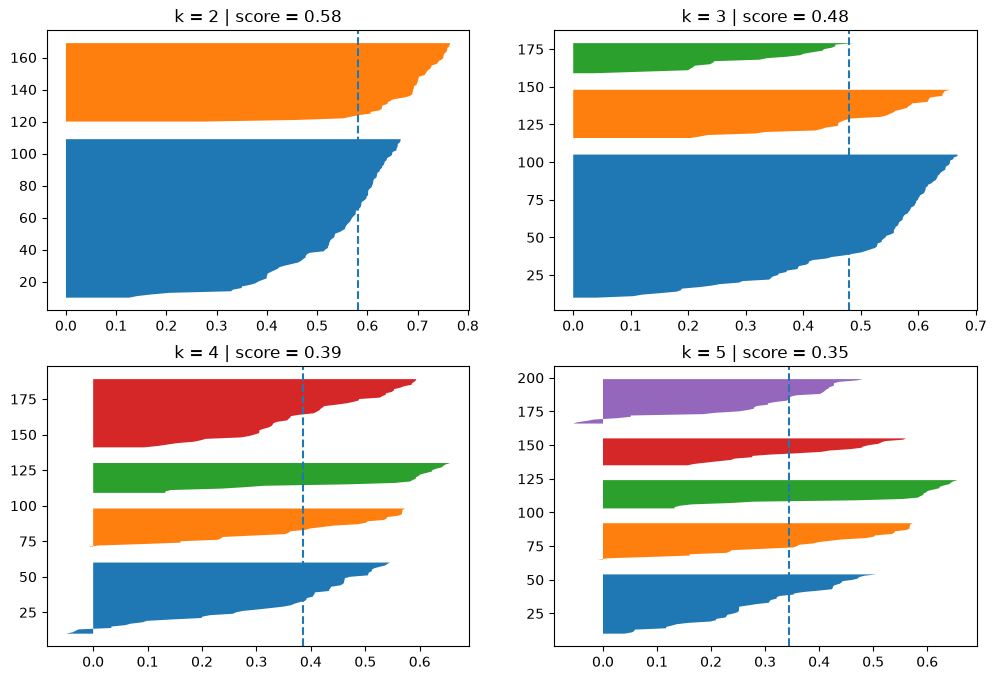

In [22]:
# Silhouette diagram

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8)
)

for ax, k in zip(axes.ravel(), ks):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(x)

    silhouette_values = silhouette_samples(
        x,
        labels
    )

    avg_score = silhouette_values.mean()

    y_lower = 10

    for cluster in range(k):

        cluster_values = silhouette_values[
            labels == cluster
        ]

        cluster_values.sort()

        size = len(cluster_values)
        y_upper = y_lower + size

        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            cluster_values
        )

        y_lower = y_upper + 10

    ax.axvline(
        avg_score,
        linestyle="--"
    )

    ax.set_title(
        f"k = {k} | score = {avg_score:.2f}"
    )


score 4 and 5 is negative so we will consider 2 and 3 .. 2 have high value.

In [37]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(x)

In [38]:
df['cluster'] = labels

print(df.head(10))
print(df['cluster'].value_counts())

     0    1    2    3  cluster  cluster3
0  5.1  3.5  1.4  0.2        1         1
1  4.9  3.0  1.4  0.2        1         1
2  4.7  3.2  1.3  0.2        1         1
3  4.6  3.1  1.5  0.2        1         1
4  5.0  3.6  1.4  0.2        1         1
5  5.4  3.9  1.7  0.4        1         1
6  4.6  3.4  1.4  0.3        1         1
7  5.0  3.4  1.5  0.2        1         1
8  4.4  2.9  1.4  0.2        1         1
9  4.9  3.1  1.5  0.1        1         1
cluster
0    100
1     50
Name: count, dtype: int64


In [39]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels1 = kmeans.fit_predict(x)

In [40]:
df['cluster3'] = labels1

print(df.head(10))

     0    1    2    3  cluster  cluster3
0  5.1  3.5  1.4  0.2        1         1
1  4.9  3.0  1.4  0.2        1         1
2  4.7  3.2  1.3  0.2        1         1
3  4.6  3.1  1.5  0.2        1         1
4  5.0  3.6  1.4  0.2        1         1
5  5.4  3.9  1.7  0.4        1         1
6  4.6  3.4  1.4  0.3        1         1
7  5.0  3.4  1.5  0.2        1         1
8  4.4  2.9  1.4  0.2        1         1
9  4.9  3.1  1.5  0.1        1         1


In [41]:
print(df['cluster3'].value_counts())

cluster3
0    53
1    50
2    47
Name: count, dtype: int64
